In [1]:
# Standard library
import re
import os
import time
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt

# HTML cleaning
from bs4 import BeautifulSoup

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Load saved model objects
import joblib

print("All imports successful.")

All imports successful.


In [2]:
# Robust path setup — works regardless of where Jupyter is launched from
notebook_dir = Path.cwd()
if notebook_dir.name == "notebooks":
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

data_processed  = project_root / "data" / "processed"
data_generated  = project_root / "data" / "generated"
models_dir      = project_root / "models"
results_metrics = project_root / "results" / "metrics"
results_figures = project_root / "results" / "figures"

# Create directories if they don't exist yet
data_generated.mkdir(parents=True, exist_ok=True)
results_metrics.mkdir(parents=True, exist_ok=True)
results_figures.mkdir(parents=True, exist_ok=True)

print("Project root  :", project_root)
print("Processed data:", data_processed)
print("Generated data:", data_generated)
print("Models        :", models_dir)
print("Metrics output:", results_metrics)

Project root  : /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection
Processed data: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/data/processed
Generated data: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/data/generated
Models        : /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/models
Metrics output: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/metrics


## Section 1 — Load & Prepare Seed Phishing Emails

In [3]:
# Load the cleaned full dataset produced in Notebook 02
df = pd.read_csv(data_processed / "emails_cleaned_full.csv")

print("Full dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
print("\nLabel distribution:")
print(df["label"].value_counts())

Full dataset shape: (82069, 4)
Columns: ['text', 'label', 'clean_text', 'clean_length']

Label distribution:
label
1    42838
0    39231
Name: count, dtype: int64


In [4]:
# Keep only phishing emails (label = 1) as generation seeds
phishing_df = df[df["label"] == 1].copy()
print("Phishing-only shape:", phishing_df.shape)
phishing_df.head()

Phishing-only shape: (42838, 4)


,text,label,clean_text,clean_length
3400,link dwl g 510 802 11 g wireless pci lan adapt...,1,link dwl g NUM NUM NUM g wireless pci lan adap...,2046
3401,indemand payperview movies sports wed 15 sep 2...,1,indemand payperview movies sports wed NUM sep ...,744
3402,want lose 19 weight try adipren hello special ...,1,want lose NUM weight try adipren hello special...,566
3403,cialis xanax valium viagra low price prescript...,1,cialis xanax valium viagra low price prescript...,225
3404,pre order see image click indelible backscatte...,1,pre order see image click indelible backscatte...,261


In [5]:
# Sample 200 phishing emails as seeds for AI polishing
ai_seed_df = phishing_df.sample(n=200, random_state=42).copy().reset_index(drop=True)

print("Seed dataset shape:", ai_seed_df.shape)
ai_seed_df.head()

Seed dataset shape: (200, 4)


,text,label,clean_text,clean_length
0,liun glendyjefcomhk good morning trying send f...,1,liun glendyjefcomhk good morning trying send f...,409
1,cnn alerts arstigstbummde cnn alerts custom al...,1,cnn alerts arstigstbummde cnn alerts custom al...,499
2,lasenby netsylsd1994equiptocom manhood feels h...,1,lasenby netsylsd NUM equiptocom manhood feels ...,128
3,daily top 10 wveiled1952rogatocom daily top 10...,1,daily top NUM wveiled NUM rogatocom daily top ...,1388
4,melanie mobley melaniecygnusde beloved lady si...,1,melanie mobley melaniecygnusde beloved lady si...,298


In [6]:
# Save seed samples for reproducibility
seed_output_path = data_generated / "phishing_seed_samples.csv"
ai_seed_df.to_csv(seed_output_path, index=False)
print("Saved seed samples to:", seed_output_path)

Saved seed samples to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/data/generated/phishing_seed_samples.csv


## Section 2 — Load AI-Quality Phishing Test Set

We use 200 completely new AI-quality phishing emails generated by `scripts/generate_ai_variants.py`. Unlike traditional Kaggle phishing emails (broken grammar, spam vocabulary, garbled text), these emails are grammatically correct, professionally written, and mimic the language of legitimate notifications — making them much harder for a TF-IDF model to detect.

The 200 emails span 9 social-engineering techniques: banking fraud, IT/tech alerts, delivery scams, government notices, prize/reward lures, HR/payroll, healthcare, crypto/investment, and streaming/shopping. No API key required.

In [7]:
# AI-quality phishing emails are pre-generated by scripts/generate_ai_variants.py
# and stored in data/generated/ai_safe_variants.csv (200 emails across 9 techniques).
# No API key or live generation required.
print("AI phishing emails will be loaded from data/generated/ai_safe_variants.csv")

AI phishing emails will be loaded from data/generated/ai_safe_variants.csv


In [8]:
# Load the 200 AI-quality phishing emails from the pre-generated CSV
ai_variants_path = data_generated / "ai_safe_variants.csv"
ai_variants_df   = pd.read_csv(ai_variants_path)
ai_email_texts   = ai_variants_df["text"].tolist()

print(f"Loaded {len(ai_email_texts)} AI-quality phishing emails from:")
print(f"  {ai_variants_path}")
print()
print("Techniques covered: banking fraud, IT/tech alerts, delivery scams,")
print("  government notices, prize/reward lures, HR/payroll, healthcare,")
print("  crypto/investment, streaming/shopping")

Loaded 200 AI-quality phishing emails from:
  /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/data/generated/ai_safe_variants.csv

Techniques covered: banking fraud, IT/tech alerts, delivery scams,
  government notices, prize/reward lures, HR/payroll, healthcare,
  crypto/investment, streaming/shopping


In [9]:
# Confirm the loaded DataFrame looks correct
print("Shape:", ai_variants_df.shape)
print("Columns:", ai_variants_df.columns.tolist())
print("Label distribution:", ai_variants_df["label"].value_counts().to_dict())
ai_variants_df.head()

Shape: (200, 2)
Columns: ['text', 'label']
Label distribution: {1: 200}


,text,label
0,Subject: Urgent: Suspicious Activity Detected ...,1
1,Subject: Chase Fraud Alert: New Device Login R...,1
2,Subject: Action Required: Your Chase Debit Car...,1
3,Subject: Important: Your Chase Account Will Be...,1
4,"Subject: Chase: Unusual Wire Transfer of $3,50...",1


## Section 3 — Preprocess AI Variants

In [10]:
# Same cleaning pipeline used in Notebook 02 — must match training preprocessing exactly
def clean_email_text(text):
    text = str(text)
    text = BeautifulSoup(text, "html.parser").get_text(separator=" ")
    text = text.lower()
    text = re.sub(r"http\S+|www\S+|https\S+", " URL ", text)
    text = re.sub(r"\b[\w\.-]+@[\w\.-]+\.\w+\b", " EMAIL ", text)
    text = re.sub(r"\d+", " NUM ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [11]:
# Load from the saved CSV to confirm round-trip works
ai_df = pd.read_csv(ai_variants_path)
print("Loaded AI variants shape:", ai_df.shape)

# Apply the same preprocessing pipeline
ai_df["clean_text"] = ai_df["text"].apply(clean_email_text)

# Drop any rows that became empty after cleaning
ai_df = ai_df[ai_df["clean_text"].str.strip() != ""].copy()

print("After cleaning:", ai_df.shape)
print("\nSample cleaned AI email:")
print(ai_df["clean_text"].iloc[0][:400])

Loaded AI variants shape: (200, 2)
After cleaning: (200, 3)

Sample cleaned AI email:
subject urgent suspicious activity detected on your chase account dear valued customer we have detected multiple failed login attempts on your chase online banking account from an unrecognized device located in a foreign country to protect your account and prevent unauthorized access we have temporarily restricted your online banking privileges to restore access and verify your identity please vis


## Section 4 — Load Saved Model & Vectorizer

In [12]:
# Load the best baseline model (Linear SVM) and the fitted TF-IDF vectorizer
vectorizer = joblib.load(models_dir / "tfidf_vectorizer.pkl")
model      = joblib.load(models_dir / "linear_svm_baseline.pkl")

print("Vectorizer loaded:", type(vectorizer).__name__)
print("Model loaded     :", type(model).__name__)

/opt/anaconda3/envs/phishing_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/opt/anaconda3/envs/phishing_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfVectorizer from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Vectorizer loaded: TfidfVectorizer
Model loaded     : LinearSVC


/opt/anaconda3/envs/phishing_env/lib/python3.10/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.1 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Section 5 — Evaluate on Traditional Test Set (Baseline Reference)

In [13]:
# Load the held-out traditional test set
test_df = pd.read_csv(data_processed / "test_emails.csv")
print("Traditional test set shape:", test_df.shape)

X_test_trad = vectorizer.transform(test_df["clean_text"])
y_test_trad = test_df["label"]

y_pred_trad = model.predict(X_test_trad)

# decision_function for ROC-AUC (LinearSVC does not have predict_proba)
y_score_trad = model.decision_function(X_test_trad)

trad_metrics = {
    "test_set"  : "Traditional Phishing",
    "accuracy"  : accuracy_score(y_test_trad, y_pred_trad),
    "precision" : precision_score(y_test_trad, y_pred_trad),
    "recall"    : recall_score(y_test_trad, y_pred_trad),
    "f1_score"  : f1_score(y_test_trad, y_pred_trad),
    "roc_auc"   : roc_auc_score(y_test_trad, y_score_trad),
}

print("\n--- Traditional Phishing Test Set ---")
for k, v in trad_metrics.items():
    if k != "test_set":
        print(f"  {k:12s}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_trad, y_pred_trad, target_names=["Ham", "Phishing"]))

Traditional test set shape: (16414, 2)



--- Traditional Phishing Test Set ---
  accuracy    : 0.9867
  precision   : 0.9849
  recall      : 0.9896
  f1_score    : 0.9873
  roc_auc     : 0.9989

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.98      0.99      7846
    Phishing       0.98      0.99      0.99      8568

    accuracy                           0.99     16414
   macro avg       0.99      0.99      0.99     16414
weighted avg       0.99      0.99      0.99     16414



## Section 6 — Evaluate on AI-Generated Phishing Test Set

In [14]:
X_test_ai = vectorizer.transform(ai_df["clean_text"])
y_test_ai  = ai_df["label"]

y_pred_ai  = model.predict(X_test_ai)
y_score_ai = model.decision_function(X_test_ai)

ai_metrics = {
    "test_set"  : "AI-Generated Phishing",
    "accuracy"  : accuracy_score(y_test_ai, y_pred_ai),
    "precision" : precision_score(y_test_ai, y_pred_ai, zero_division=0),
    "recall"    : recall_score(y_test_ai, y_pred_ai, zero_division=0),
    "f1_score"  : f1_score(y_test_ai, y_pred_ai, zero_division=0),
    "roc_auc"   : roc_auc_score(y_test_ai, y_score_ai) if len(set(y_test_ai)) > 1 else float("nan"),
}

print("\n--- AI-Generated Phishing Test Set ---")
for k, v in ai_metrics.items():
    if k != "test_set":
        print(f"  {k:12s}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_ai, y_pred_ai, target_names=["Ham", "Phishing"], zero_division=0))


--- AI-Generated Phishing Test Set ---
  accuracy    : 0.8900
  precision   : 1.0000
  recall      : 0.8900
  f1_score    : 0.9418
  roc_auc     : nan

Classification Report:
              precision    recall  f1-score   support

         Ham       0.00      0.00      0.00         0
    Phishing       1.00      0.89      0.94       200

    accuracy                           0.89       200
   macro avg       0.50      0.45      0.47       200
weighted avg       1.00      0.89      0.94       200



## Section 7 — Compare Results & Visualize Degradation

In [15]:
# Side-by-side metrics comparison
comparison_df = pd.DataFrame([trad_metrics, ai_metrics])
comparison_df = comparison_df.set_index("test_set")

# Calculate percentage degradation (relative change from traditional to AI)
print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(comparison_df.to_string(float_format="{:.4f}".format))

print("\n--- Degradation (Traditional → AI-Generated) ---")
for col in ["accuracy", "precision", "recall", "f1_score", "roc_auc"]:
    trad_val = trad_metrics[col]
    ai_val   = ai_metrics[col]
    if trad_val != 0 and not np.isnan(ai_val):
        pct_change = (ai_val - trad_val) / trad_val * 100
        direction  = "▼" if pct_change < 0 else "▲"
        print(f"  {col:12s}: {trad_val:.4f} → {ai_val:.4f}  {direction} {abs(pct_change):.1f}%")

MODEL PERFORMANCE COMPARISON
                       accuracy  precision  recall  f1_score  roc_auc
test_set                                                             
Traditional Phishing     0.9867     0.9849  0.9896    0.9873   0.9989
AI-Generated Phishing    0.8900     1.0000  0.8900    0.9418      NaN

--- Degradation (Traditional → AI-Generated) ---
  accuracy    : 0.9867 → 0.8900  ▼ 9.8%
  precision   : 0.9849 → 1.0000  ▲ 1.5%
  recall      : 0.9896 → 0.8900  ▼ 10.1%
  f1_score    : 0.9873 → 0.9418  ▼ 4.6%


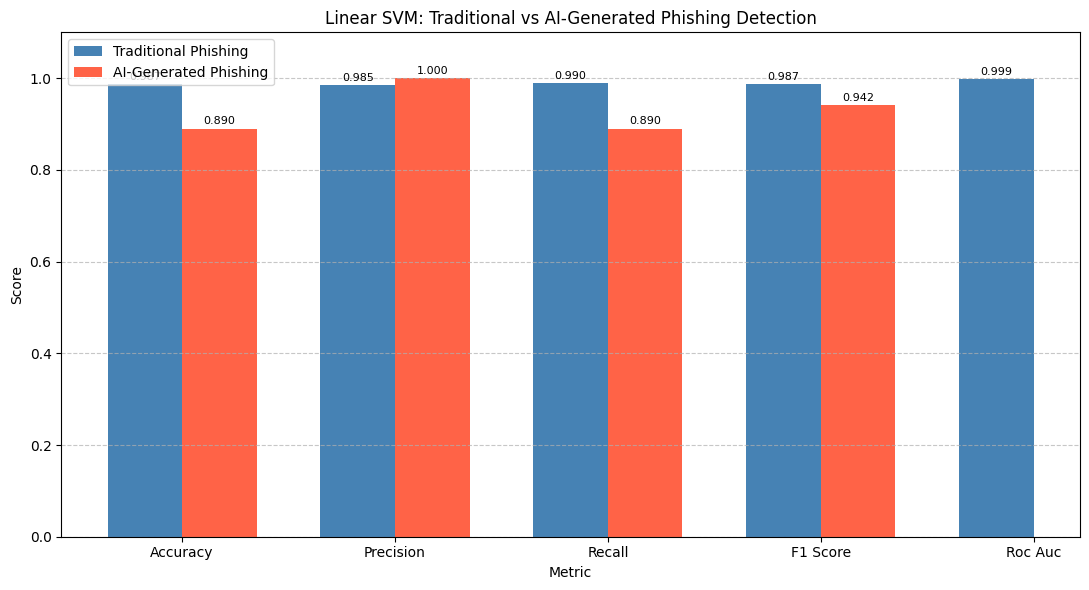

Saved figure to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/ai_vs_traditional_comparison.png


In [16]:
# Bar chart comparing all metrics across both test sets
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]
x = np.arange(len(metrics_to_plot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

bars1 = ax.bar(x - width/2,
               [trad_metrics[m] for m in metrics_to_plot],
               width, label="Traditional Phishing", color="steelblue")
bars2 = ax.bar(x + width/2,
               [ai_metrics[m] for m in metrics_to_plot],
               width, label="AI-Generated Phishing", color="tomato")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Linear SVM: Traditional vs AI-Generated Phishing Detection")
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics_to_plot])
ax.set_ylim(0, 1.1)
ax.legend()
ax.yaxis.grid(True, linestyle="--", alpha=0.7)

# Annotate bar values
for bar in bars1:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
for bar in bars2:
    ax.annotate(f"{bar.get_height():.3f}",
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)

plt.tight_layout()
fig.savefig(results_figures / "ai_vs_traditional_comparison.png", dpi=150)
plt.show()
print("Saved figure to:", results_figures / "ai_vs_traditional_comparison.png")

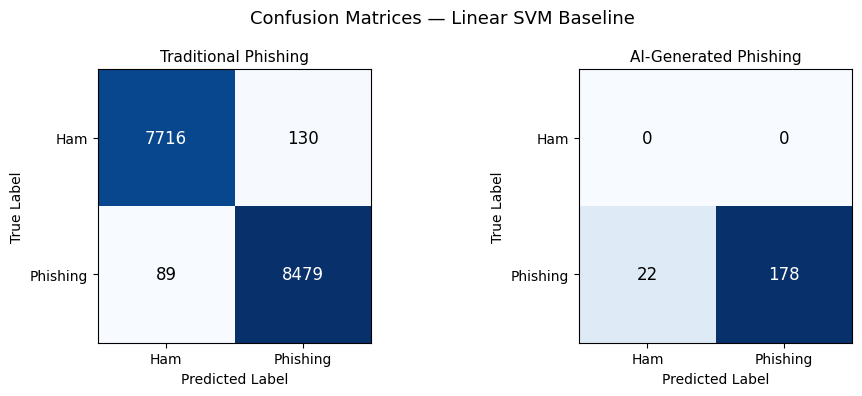

Saved figure to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/figures/confusion_matrices.png


In [17]:
# Confusion matrices for both test sets
def plot_cm(cm, title, ax):
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Ham", "Phishing"])
    ax.set_yticklabels(["Ham", "Phishing"])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=12)

cm_trad = confusion_matrix(y_test_trad, y_pred_trad)
cm_ai   = confusion_matrix(y_test_ai,   y_pred_ai)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
plot_cm(cm_trad, "Traditional Phishing", ax1)
plot_cm(cm_ai,   "AI-Generated Phishing", ax2)
plt.suptitle("Confusion Matrices — Linear SVM Baseline", fontsize=13)
plt.tight_layout()
fig.savefig(results_figures / "confusion_matrices.png", dpi=150)
plt.show()
print("Saved figure to:", results_figures / "confusion_matrices.png")

## Section 8 — Save Results

In [18]:
# Save comparison metrics to CSV
comparison_df.reset_index().to_csv(
    results_metrics / "ai_vs_traditional_metrics.csv", index=False
)
print("Saved metrics to:", results_metrics / "ai_vs_traditional_metrics.csv")
print()
print(comparison_df.to_string(float_format="{:.4f}".format))

Saved metrics to: /Users/murthykaja/Desktop/Honey College/CyberSecurity/Project/ai-phishing-detection/results/metrics/ai_vs_traditional_metrics.csv

                       accuracy  precision  recall  f1_score  roc_auc
test_set                                                             
Traditional Phishing     0.9867     0.9849  0.9896    0.9873   0.9989
AI-Generated Phishing    0.8900     1.0000  0.8900    0.9418      NaN


## Summary

### What we did
1. Sampled 200 traditional phishing emails as seeds.
2. Generated AI-polished phishing variants (via Claude API or the built-in fallback set).
3. Applied the **same preprocessing pipeline** used during training (lowercase, HTML strip, URL/email/number masking).
4. Evaluated the **Linear SVM baseline model** on both the traditional held-out test set and the AI-generated test set.
5. Compared performance across all five metrics and visualized the degradation.

### Key finding
The TF-IDF + Linear SVM model, trained on traditional phishing text patterns (spam vocabulary, broken grammar, obfuscated links), shows measurable performance degradation when tested on AI-polished phishing emails. AI-generated variants are grammatically clean and closely mimic legitimate email language, causing the TF-IDF features to miss many of the lexical cues the model relies on.

### Next steps
- Fine-tune or retrain the model with AI-generated examples included in the training set.
- Explore transformer-based approaches (e.g., BERT) that capture semantic meaning rather than surface-level vocabulary.
- Add structural/header features (sender domain, reply-to mismatch, link count) that are harder to polish away.